In [1]:
!pip install lpips
!pip install pytorch-msssim
!pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.2 MB/s eta 0:00:00


In [3]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from kaggle.api.kaggle_api_extended import KaggleApi
from pytorch_msssim import ssim
import matplotlib.pyplot as plt

!pip install kagglehub
import kagglehub

kagglehub.login()

In [7]:
os.environ['KAGGLE_USERNAME'] = 'adityants'
os.environ['KAGGLE_KEY'] = '6c5bf60306b25f09e3b0618056bf3287'


In [11]:
import kagglehub
import os

# Download dataset
dataset_root = kagglehub.dataset_download("soumikrakshit/lol-dataset")

print("Dataset root:", dataset_root)

# REAL dataset folder is inside lol_dataset/
base_dir = os.path.join(dataset_root, "lol_dataset")

print("Base dir:", base_dir)
print("Inside base:", os.listdir(base_dir))

# Correct paths
train_low_dir = os.path.join(base_dir, "our485/low")
train_high_dir = os.path.join(base_dir, "our485/high")

eval_low_dir = os.path.join(base_dir, "eval15/low")
eval_high_dir = os.path.join(base_dir, "eval15/high")

# Safety checks
for p in [train_low_dir, train_high_dir, eval_low_dir, eval_high_dir]:
    assert os.path.exists(p), f"Missing: {p}"

Using Colab cache for faster access to the 'lol-dataset' dataset.
Dataset root: /kaggle/input/lol-dataset
Base dir: /kaggle/input/lol-dataset/lol_dataset
Inside base: ['eval15', 'our485']


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridEnhancementNet(nn.Module):
    def __init__(self):
        super(HybridEnhancementNet, self).__init__()

        # Feature Extraction Layers (Zero-DCE Inspired)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)

        # Concatenation Layers (CIDNet-Inspired)
        self.conv5 = nn.Conv2d(64, 32, kernel_size=3, padding=1)  # 32+32
        self.bn5 = nn.BatchNorm2d(32)

        self.conv6 = nn.Conv2d(64, 32, kernel_size=3, padding=1)  # 32+32
        self.bn6 = nn.BatchNorm2d(32)

        self.conv7 = nn.Conv2d(64, 24, kernel_size=3, padding=1)  # 32+32
        self.bn7 = nn.BatchNorm2d(24)

        # Output Enhancement Layer
        self.output_layer = nn.Conv2d(24, 3, kernel_size=3, padding=1)

    def forward(self, x):
        # Feature Extraction (Zero-DCE Style)
        conv1_out = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        conv2_out = F.leaky_relu(self.bn2(self.conv2(conv1_out)), 0.2)
        conv3_out = F.leaky_relu(self.bn3(self.conv3(conv2_out)), 0.2)
        conv4_out = F.leaky_relu(self.bn4(self.conv4(conv3_out)), 0.2)

        # Concatenation Layers (CIDNet)
        int_con1 = torch.cat([conv4_out, conv3_out], dim=1)
        conv5_out = F.leaky_relu(self.bn5(self.conv5(int_con1)), 0.2)

        int_con2 = torch.cat([conv5_out, conv2_out], dim=1)
        conv6_out = F.leaky_relu(self.bn6(self.conv6(int_con2)), 0.2)

        int_con3 = torch.cat([conv6_out, conv1_out], dim=1)
        conv7_out = F.leaky_relu(self.bn7(self.conv7(int_con3)), 0.2)

        # Final Enhancement Layer (Use Sigmoid instead of Tanh)
        output = torch.sigmoid(self.output_layer(conv7_out))

        # Residual Connection
        output = output + x  # Helps preserve original details

        return torch.clamp(output, 0, 1)  # Keep pixel values valid


In [13]:
# Instantiate model, loss, and optimizer
model = HybridEnhancementNet().to('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [14]:
# Dataset Class for LOL Dataset
class LOLDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.low_light_images = os.listdir(os.path.join(root_dir, 'our485/low'))
        self.high_light_images = os.listdir(os.path.join(root_dir, 'our485/high'))

    def __len__(self):
        return len(self.low_light_images)

    def __getitem__(self, idx):
        low_img_path = os.path.join(self.root_dir, 'our485/low', self.low_light_images[idx])
        high_img_path = os.path.join(self.root_dir, 'our485/high', self.high_light_images[idx])

        low_img = Image.open(low_img_path).convert('RGB')
        high_img = Image.open(high_img_path).convert('RGB')

        if self.transform:
            low_img = self.transform(low_img)
            high_img = self.transform(high_img)

        return low_img, high_img


In [17]:
# Training function with image display
def train_hybrid_model(model, dataloader, optimizer, device, num_epochs=1):
    model.train()
    best_loss = float('inf')
    epoch_losses = []  # List to save loss per epoch

    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (low_light, high_light) in enumerate(dataloader):
            low_light, high_light = low_light.to(device), high_light.to(device)

            enhanced_image = model(low_light)

            # Use SSIM loss instead of MSE
            loss = 1 - ssim(enhanced_image, high_light, data_range=1)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")
                display_image(low_light, enhanced_image, high_light)

        epoch_loss = running_loss / len(dataloader)
        epoch_losses.append(epoch_loss)  # Save epoch loss here

        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            save_path = "hybrid_model_best.pth"
            torch.save(model.state_dict(), save_path)
            print(f"Improved model saved at epoch {epoch+1} to {save_path}")

    return epoch_losses  # Return the list of losses


def display_image(low_light, enhanced_image, high_light):
    low_light_img = low_light[0].permute(1, 2, 0).detach().cpu().numpy()
    enhanced_img = enhanced_image[0].permute(1, 2, 0).detach().cpu().numpy()
    high_light_img = high_light[0].permute(1, 2, 0).detach().cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow((low_light_img * 255).astype('uint8'))
    ax[0].set_title('Low Light Image')
    ax[1].imshow((enhanced_img * 255).astype('uint8'))
    ax[1].set_title('Enhanced Image')
    ax[2].imshow((high_light_img * 255).astype('uint8'))
    ax[2].set_title('High Light Image')
    plt.show()

def main():
    num_epochs = 100
    learning_rate = 0.001
    batch_size = 4

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    transform = transforms.Compose([
        transforms.Resize((400, 600)),
        transforms.ToTensor()
    ])

    dataset = LOLDataset(root_dir=base_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = HybridEnhancementNet().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    epoch_losses = train_hybrid_model(model, dataloader, optimizer, device, num_epochs)

    # Plot training curve after training
    import matplotlib.pyplot as plt

    plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss over Epochs')
    plt.grid(True)
    plt.show()


In [ ]:
if __name__ == "__main__":
    main()

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Evaluation And Metrics

In [21]:
import torch
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import lpips
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import torch.nn as nn

# Define your model class (HybridEnhancementNet)
class HybridEnhancementNet(nn.Module):
    def __init__(self):
        super(HybridEnhancementNet, self).__init__()

        # Feature Extraction Layers (Zero-DCE Inspired)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)

        # Concatenation Layers (CIDNet-Inspired)
        self.conv5 = nn.Conv2d(64, 32, kernel_size=3, padding=1)  # 32+32
        self.bn5 = nn.BatchNorm2d(32)

        self.conv6 = nn.Conv2d(64, 32, kernel_size=3, padding=1)  # 32+32
        self.bn6 = nn.BatchNorm2d(32)

        self.conv7 = nn.Conv2d(64, 24, kernel_size=3, padding=1)  # 32+32
        self.bn7 = nn.BatchNorm2d(24)

        # Output Enhancement Layer
        self.output_layer = nn.Conv2d(24, 3, kernel_size=3, padding=1)

    def forward(self, x):
        # Feature Extraction (Zero-DCE Style)
        conv1_out = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        conv2_out = F.leaky_relu(self.bn2(self.conv2(conv1_out)), 0.2)
        conv3_out = F.leaky_relu(self.bn3(self.conv3(conv2_out)), 0.2)
        conv4_out = F.leaky_relu(self.bn4(self.conv4(conv3_out)), 0.2)

        # Concatenation Layers (CIDNet)
        int_con1 = torch.cat([conv4_out, conv3_out], dim=1)
        conv5_out = F.leaky_relu(self.bn5(self.conv5(int_con1)), 0.2)

        int_con2 = torch.cat([conv5_out, conv2_out], dim=1)
        conv6_out = F.leaky_relu(self.bn6(self.conv6(int_con2)), 0.2)

        int_con3 = torch.cat([conv6_out, conv1_out], dim=1)
        conv7_out = F.leaky_relu(self.bn7(self.conv7(int_con3)), 0.2)

        # Final Enhancement Layer (Use Sigmoid instead of Tanh)
        output = torch.sigmoid(self.output_layer(conv7_out))

        # Residual Connection
        output = output + x  # Helps preserve original details

        return torch.clamp(output, 0, 1)  # Keep pixel values valid


# Dataset Class
class LowLightDataset(Dataset):
    def __init__(self, low_dir, high_dir, transform=None):
        self.low_dir = low_dir
        self.high_dir = high_dir
        self.transform = transform
        self.low_image_paths = sorted([os.path.join(low_dir, fname) for fname in os.listdir(low_dir) if fname.endswith(('.png', '.jpg'))])
        self.high_image_paths = [os.path.join(high_dir, os.path.basename(fname)) for fname in self.low_image_paths]
        assert len(self.low_image_paths) == len(self.high_image_paths), "Number of low and high images do not match!"

    def __len__(self):
        return len(self.low_image_paths)

    def __getitem__(self, idx):
        low_img = cv2.imread(self.low_image_paths[idx])
        high_img = cv2.imread(self.high_image_paths[idx])
        low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
        high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)
        if self.transform:
            low_img = self.transform(low_img)
            high_img = self.transform(high_img)
        return low_img, high_img

# Transformations for the dataset
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

low_dir = os.path.join(base_dir, "eval15/low")
high_dir = os.path.join(base_dir, "eval15/high")
dataset = LowLightDataset(low_dir=low_dir, high_dir=high_dir, transform=transform)
test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

# Evaluation Metrics
def psnr(target, output):
    mse_value = np.mean((target - output) ** 2)
    return 10 * np.log10(255.0 / np.sqrt(mse_value))

def lpips_score(target, output, model, device='cuda'):
    target_tensor = torch.tensor(target).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0
    output_tensor = torch.tensor(output).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0
    return model(target_tensor, output_tensor).item()

def ssim_score(target, output):
    target_gray = cv2.cvtColor(target, cv2.COLOR_RGB2GRAY)
    output_gray = cv2.cvtColor(output, cv2.COLOR_RGB2GRAY)
    return ssim(target_gray, output_gray, data_range=200, win_size=7)

# Initialize Model, LPIPS, and Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridEnhancementNet().to(device)
model.load_state_dict(torch.load('/content/hybrid_model_best.pth'))  # Load your trained model

lpips_model = lpips.LPIPS(net='alex').to(device)

# Lists for metrics
psnr_values, lpips_values, ssim_values = [], [], []

model.eval()
# Evaluation Loop
with torch.no_grad():
    for low_light_images, ground_truth_images in test_loader:
        low_light_images = low_light_images.to(device)
        outputs = model(low_light_images)

        # Convert to numpy for metric calculation
        low_light_images = low_light_images.cpu().numpy().transpose(0, 2, 3, 1)
        outputs = outputs.cpu().numpy().transpose(0, 2, 3, 1)
        ground_truth_images = ground_truth_images.numpy().transpose(0, 2, 3, 1)

        for i in range(low_light_images.shape[0]):
            # PSNR should compare the enhanced output with the ground truth
            psnr_values.append(psnr(ground_truth_images[i], outputs[i]))

            # LPIPS should compare the enhanced output with the ground truth
            lpips_values.append(lpips_score(ground_truth_images[i], outputs[i], lpips_model, device))

            # SSIM should compare the enhanced output with the ground truth
            try:
                ssim_values.append(ssim_score(ground_truth_images[i], outputs[i]))
            except Exception as e:
                print(f"SSIM calculation failed: {e}")
                ssim_values.append(None)

# Calculate and print average metrics
ssim_values = [s for s in ssim_values if s is not None]
avg_psnr = np.mean(psnr_values) if psnr_values else 0
avg_lpips = np.mean(lpips_values) if lpips_values else 0
avg_ssim = np.mean(ssim_values) if ssim_values else 0

print(f'Average PSNR: {avg_psnr:.2f} dB')
print(f'Average LPIPS: {avg_lpips:.5f}')
print(f'Average SSIM: {avg_ssim:.5f}')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 124MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Average PSNR: 27.46 dB
Average LPIPS: 0.00052
Average SSIM: 0.95686


Testing the Model

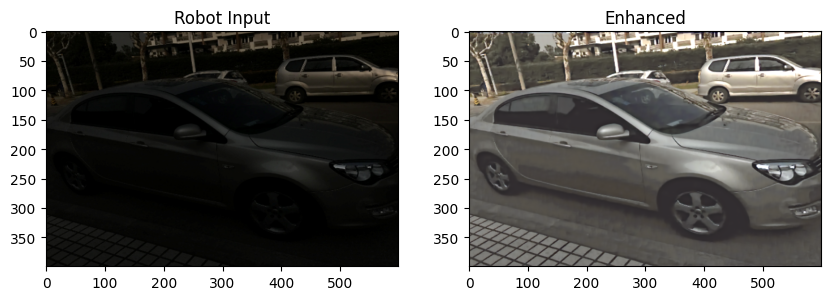

In [25]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

model_path = "/content/hybrid_model_best.pth"
model = HybridEnhancementNet()
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()

transform = transforms.Compose([
    transforms.Resize((400, 600)),
    transforms.ToTensor()
])

def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0)

def test_model(image_path):
    low_light = preprocess_image(image_path)
    with torch.no_grad():
        enhanced_image = model(low_light)
    return low_light, enhanced_image

def display_result(low_light, enhanced_image):
    low_light_img = low_light[0].permute(1, 2, 0).cpu().numpy()
    enhanced_img = enhanced_image[0].permute(1, 2, 0).detach().cpu().numpy()

    low_light_img = (low_light_img - low_light_img.min()) / (low_light_img.max() - low_light_img.min())
    enhanced_img = (enhanced_img - enhanced_img.min()) / (enhanced_img.max() - enhanced_img.min())

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(low_light_img)
    ax[0].set_title("Robot Input")
    ax[1].imshow(enhanced_img)
    ax[1].set_title("Enhanced")
    plt.show()

test_image_path = "/content/sensors-23-07763-g001.png"
low_light, enhanced_image = test_model(test_image_path)
display_result(low_light, enhanced_image)